In [15]:
import pandas as pd
import numpy as np

# 1) chemin du fichier
path = "/content/sample_data/PIB_growht.xlsx"

df1 = pd.read_excel(path)
df1.head()

,Période,PIB_growth
0,2000-Q4,0.6
1,2001-Q1,0.5
2,2001-Q2,0.0
3,2001-Q3,0.6
4,2001-Q4,-0.4


In [16]:
df_pib = df1.rename(columns={"Période": "period"})

df_pib.index = pd.PeriodIndex(df_pib["period"], freq="Q").to_timestamp(how="end")

df_pib = df_pib.drop(columns="period")

df_pib.head()


,PIB_growth
period,
2000-12-31 23:59:59.999999999,0.6
2001-03-31 23:59:59.999999999,0.5
2001-06-30 23:59:59.999999999,0.0
2001-09-30 23:59:59.999999999,0.6
2001-12-31 23:59:59.999999999,-0.4


In [17]:
path = "/content/sample_data/IPI_growth.xlsx"
df2= pd.read_excel(path)
df2.head()

,date,IPI_growth
0,2024-12-01,-0.346724
1,2024-11-01,-0.108723
2,2024-10-01,-0.207234
3,2024-09-01,-0.403365
4,2024-08-01,0.758886


In [18]:
df_ipi = df2.copy()

df_ipi["date"] = pd.to_datetime(df_ipi["date"])
df_ipi = df_ipi.set_index("date")

df_ipi.head()


,IPI_growth
date,
2024-12-01,-0.346724
2024-11-01,-0.108723
2024-10-01,-0.207234
2024-09-01,-0.403365
2024-08-01,0.758886


In [19]:
ipi_q = (
    df_ipi["IPI_growth"]
    .resample("QE")
    .mean()
    .to_frame(name="IPI_growth_q")
)

ipi_q.head()


,IPI_growth_q
date,
2000-03-31,0.587293
2000-06-30,0.168487
2000-09-30,0.170626
2000-12-31,0.627052
2001-03-31,0.224861


In [20]:
df_pib = df_pib.copy()
df_pib.index = df_pib.index.to_period("Q").to_timestamp("Q")


In [21]:
df_merge = ipi_q.join(df_pib, how="inner")

df_merge.head()


,IPI_growth_q,PIB_growth
2000-12-31,0.627052,0.6
2001-03-31,0.224861,0.5
2001-06-30,-0.277645,0.0
2001-09-30,-0.126435,0.6
2001-12-31,-0.391150,-0.4


In [22]:
df_merge.isna().sum()


,0
IPI_growth_q,0
PIB_growth,0


In [23]:
# Corrélation de Pearson (relation linéaire)
corr_pearson = df_merge["IPI_growth_q"].corr(df_merge["PIB_growth"])

# Corrélation de Spearman (robuste aux chocs extrêmes, ex. 2020)
corr_spearman = df_merge["IPI_growth_q"].corr(
    df_merge["PIB_growth"], method="spearman"
)

corr_pearson, corr_spearman


(np.float64(0.31206431457713746), np.float64(0.4432430886815354))

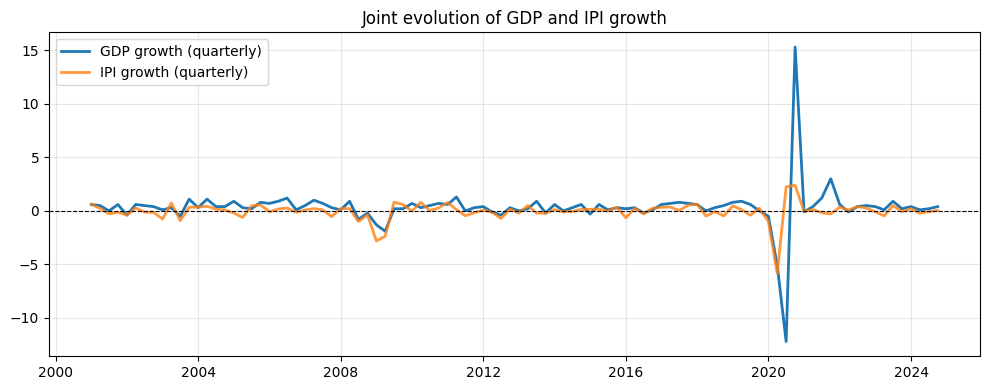

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(df_merge.index, df_merge["PIB_growth"],
         label="GDP growth (quarterly)", linewidth=2)

plt.plot(df_merge.index, df_merge["IPI_growth_q"],
         label="IPI growth (quarterly)", linewidth=2, alpha=0.8)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.title("Joint evolution of GDP and IPI growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
